# LC8 — CIM-XML: from grid snapshots to time series (self-paced, ~40 min)

The Svedala CSVs you have trusted for two courses were *derived* — this is the source: four CIM-XML files in the CGMES standard, the format European TSOs actually exchange grids in. EG2130 introduced the structural side (if that course is not in your past, the table in section 1 is all you need); here we recap it briefly and then focus on what EG2130 never used: **SSH files as operating-state snapshots, and a folder of them as a time series**. Material from this notebook appears in **Quiz 3**; Lab 6 does the real work.

**How to use this notebook:** run the cells top to bottom, one at a time. Every code cell has a note above it saying what it is for and what you should see; the numbers quoted are the ones these files produce. If what you see differs, stop and ask your pod.

## 0. Before you start: opening the notebook on your laptop

Local, not Colab — it reads 8 MB of XML from the course repository. From a terminal with your workbook's venv active (the Lab 1 one):

```bash
pip install jupyterlab            # once; a tool for you, not a dependency of the toolbox
cd <path to your clone of>/course-material/notebooks
jupyter lab                       # opens in your browser; double-click LC08_cim_snapshots.ipynb
```

Start Jupyter *inside* `notebooks/` — the guard cell below checks that. Shift+Enter runs a cell; the kernel offered, "Python 3 (ipykernel)", is your venv's Python when Jupyter was started from the activated venv.

## 1. Recap in one cell: four files, four jobs

| Profile | Answers | Changes |
|---|---|---|
| **EQ** (equipment) | what exists — buses, lines, machines, their parameters | rarely |
| **TP** (topology) | how it is connected right now | on switching |
| **SSH** (steady state hypothesis) | what everything is *doing* — load P/Q, dispatch | **every instant** |
| **SV** (state variables) | the solved result — voltages, flows | every instant |

Same grid, separated by *rate of change*. The provenance chain to your CSVs: ENTSO-E CGMES test model → these four files → a converter → `buses.csv` and friends. And the punchline of this session: EQ+TP is **the network**; a directory of timestamped SSH files is **its operational history**.

### 1.1 Setup

`%pip install` — the `%` marks a Jupyter *magic command*, here pip run from inside the notebook — puts the two libraries where the notebook can import them; `re`, `zipfile` and `pathlib` are part of Python itself. **What you see:** one "Note: you may need to restart the kernel…" line, or nothing. No restart needed.

In [1]:
# Install exactly what this notebook uses (re, zipfile, pathlib are stdlib).
%pip install pandas matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


The guard: `assert` stops here with a clear message if `../data` is missing. **What you see:** nothing — good.

In [2]:
from pathlib import Path
# Guard: this notebook expects to run from the notebooks/ folder of a clone of
# the course repository — the datasets live one level up in ../data/.
# Failing here, early and clearly, beats a confusing FileNotFoundError later.
assert Path("../data").exists(), (
    "Course data folder not found. Clone KTH-EG2140/course-material and open "
    "this notebook from its notebooks/ folder.")

### 1.2 The four files on disk

`CIM.glob("*.xml")` lists every file in the folder whose name ends in `.xml`; `sorted(...)` puts them in name order; `f.stat().st_size / 1024` is the size in kB; the `:20s` and `:7.0f` inside the f-string pad the name to 20 characters and print the size with no decimals, so the columns line up. **What you see:** four lines — `network_EQ.xml` at about 4098 kB is by far the largest (every parameter of every element), and `network_SSH.xml` at 865 kB is the other file this notebook reads.

In [3]:
from pathlib import Path
CIM = Path("../data/svedala-cim")
for f in sorted(CIM.glob("*.xml")):
    print(f"{f.name:20s} {f.stat().st_size/1024:7.0f} kB")

network_EQ.xml          4098 kB
network_SSH.xml          865 kB
network_SV.xml          1410 kB
network_TP.xml          1156 kB


## 2. Open one — it is only XML

Look at the raw text before any tool touches it. An SSH file is a list of statements: *this load draws 75 MW and 30 Mvar right now*:

`.read_text(encoding="utf-8")` reads the whole file into one string; `ssh_text[:1200]` prints its first 1200 characters. **What you see:** an XML header, a `FullModel` block whose `Model.scenarioTime` reads `2021-04-21T17:30:00Z` (the instant this snapshot describes — the `Z` means UTC), then the first `ConformLoad` blocks with `EnergyConsumer.p` and `.q` values in MW and Mvar.

In [4]:
ssh_text = (CIM / "network_SSH.xml").read_text(encoding="utf-8")
print(ssh_text[:1200])

<?xml version="1.0" encoding="UTF-8"?>
<rdf:RDF xmlns:eu="http://iec.ch/TC57/CIM100-European#" xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#" xmlns:cim="http://iec.ch/TC57/CIM100#" xmlns:md="http://iec.ch/TC57/61970-552/ModelDescription/1#">
    <md:FullModel rdf:about="urn:uuid:2cdfbce6-8ce8-7c4c-9776-3f838aa6c597_N_STEADY_STATE_HYPOTHESIS_2021-04-21T17:30:00Z_1_1D__FM">
        <md:Model.scenarioTime>2021-04-21T17:30:00Z</md:Model.scenarioTime>
        <md:Model.created>2026-03-04T18:06:56Z</md:Model.created>
        <md:Model.description>SSH Model</md:Model.description>
        <md:Model.version>1</md:Model.version>
        <md:Model.DependentOn rdf:resource="urn:uuid:2cdfbce6-8ce8-7c4c-9776-3f838aa6c597_N_EQUIPMENT_2021-04-21T17:30:00Z_1_1D__FM"/>
        <md:Model.profile>http://iec.ch/TC57/ns/CIM/SteadyStateHypothesis-EU/3.0</md:Model.profile>
        <md:Model.modelingAuthoritySet>powsybl.org</md:Model.modelingAuthoritySet>
    </md:FullModel>
    <cim:ConformLoad rdf:a

Everything hangs on the `rdf:about="#_8a28..."` identifiers — **mRIDs**, the machine-readable names. The SSH never says "AT111_T1_LAST"; human names live in EQ. Joining the two is Lab 6's first task, and it is ordinary data engineering:

### 2.1 The join, by hand

Two regular expressions do the work; read them once slowly. A pattern is written as `r'...'` — the `r` (raw) stops Python from treating backslashes specially, so `\s` reaches the regex engine intact. `re.findall(pattern, text)` returns every match as a tuple of the parenthesised groups. In the EQ pattern: `(_[0-9a-f-]+)` captures the mRID after `rdf:ID="` — one or more characters that are digits, `a` to `f`, or `-` (the dash is a literal, mRIDs contain dashes); `.*?` skips *as little as possible* until the name tag (`.` is any character, `*` any number of them, `?` makes it stop at the first chance); `([^<]+)` captures everything up to the next `<`, the name (`^` as the first thing inside square brackets means *not*: any character that is not `<`); and `re.S` lets that `.` cross line breaks, because the name sits a few lines below the ID. The dots inside `IdentifiedObject.name` are ordinary characters in the tag name, not wildcards — they happen to match themselves. `dict(list of pairs)` turns the matches into a lookup. The SSH pattern captures the mRID after `rdf:about="#` (the EQ *defines* an element with `rdf:ID`; every other file *refers* to it with `rdf:about="#…"`, hence the `#`), then `\s*` allows any whitespace, including a line break (the SSH pattern crosses its line break this way; the EQ pattern used `re.S` for the same job, because there the gap holds other tags, not just whitespace), and `([-\d.]+)` captures a number — `\d` is any digit, `.` a decimal point, `-` a possible minus sign, written first inside the brackets so it is not read as a range; `{m: float(p) for m, p in ...}` is a *dictionary comprehension* — a list comprehension that builds a dict — and the last comprehension keeps only mRIDs the EQ knows (`if m in name_of`).

The last line of the cell is a bare expression, no `print` — Jupyter shows the value of a cell's last expression on its own, which is what the `[:5]` list is doing there. **What you see:** `73 loads joined; total 10995 MW` and the first five name–MW pairs, `AT111_T1_LAST` at 75.0 MW first. Ten thousand nine hundred and ninety-five should look familiar: your `svedala pf` in Lab 1 printed a total load of 10 981 MW from the CSVs. The 14 MW gap is real and Lab 6 makes it explicit — the EQ carries 73 ConformLoads; `loads.csv` has 60 rows but 59 distinct names (one name appears twice); 55 of those names are also in the EQ; the 18 EQ-only loads (all `ST…` stations) sum to 60 MW here, and the four CSV-only names (`Equiv_LV_…`, equivalent loads the converter added, the duplicated name among them) sum to 46 MW. So 10 995 − 60 + 46 = 10 981: the two totals agree once every load is accounted for.

In [5]:
import re
# EQ: mRID -> name, for the loads
eq_text = (CIM / "network_EQ.xml").read_text(encoding="utf-8")
name_of = dict(re.findall(
    r'<cim:ConformLoad rdf:ID="(_[0-9a-f-]+)">.*?<cim:IdentifiedObject.name>([^<]+)<',
    eq_text, re.S))
# SSH: mRID -> P
p_of = {m: float(p) for m, p in re.findall(
    r'<cim:ConformLoad rdf:about="#(_[0-9a-f-]+)">\s*<cim:EnergyConsumer.p>([-\d.]+)', ssh_text)}
joined = {name_of[m]: p for m, p in p_of.items() if m in name_of}
print(len(joined), "loads joined; total", round(sum(joined.values())), "MW")
list(joined.items())[:5]

73 loads joined; total 10995 MW


[('AT111_T1_LAST', 75.0),
 ('AT111_T2_LAST', 25.0),
 ('AT241_T1_LAST', 150.0),
 ('AT241_T2_LAST', 50.0),
 ('CT11_T1_LAST', 150.0)]

### 2.2 Where this lands in your toolbox

Lab 6 asks for exactly this work as three functions in `src/svedala_toolbox/cim.py` (the stub is already in your workbook):

- `load_zone_map(eq_path, csv_dir) -> dict[str, str]` — keyed by **mRID** (the name is only a stepping stone): the EQ half of the join above (`name_of`), continued two steps: name → bus via `loads.csv`, whose `bus` column holds a number that is the *row label* of `buses.csv` — the value in its first column, which `index_col=0` makes the index, so look it up with `buses.loc[1088]`, never by position — and bus → zone via `buses.csv`. `csv_dir` is your workbook's `data/svedala/`; the EQ file you copy into the workbook in Lab 6 (4 MB, committed, so the tests can run in CI), and the week of snapshots you read by path from your course-material clone. One trap waiting there: `buses.csv` has a column called `zone` that holds the *substation* name; the `ZON_*` zone is `SubGeographicalRegion_name`, the column your Lab 1 loader used.
- `parse_ssh(source, zone_map) -> (timestamp, {zone: MW})` — the SSH half (`p_of`), summed per zone instead of per load, plus the `scenarioTime` you read in section 2.
- `assemble_series(ssh_zip, zone_map) -> DataFrame` — the loop of section 3 below, over all 168 files instead of one day.

The regex patterns above are the ones to carry over; the zone step is the only new piece.

(Real tools read RDF/XML with a parser, not regex — Python's `ElementTree`, a standard-library module that turns XML into a tree of elements you walk by tag name, with the `cim:` and `rdf:` prefixes registered so the tags resolve. Regex is used here so every step is visible in one cell, at the price of breaking if the file's layout changes. Lab 6 lets you take either route — and asks you to justify the choice in one sentence.)

## 3. A folder of snapshots IS a time series

`data/svedala-year/ssh_week.zip` holds 168 SSH files — one January week, one snapshot per hour, timestamps in the filenames and in `Model.scenarioTime`. Extract one day and watch a time series appear out of "static" network files:

### 3.1 One day, 24 files

`zipfile.ZipFile(path)` opens the archive without extracting it; `zf.namelist()` lists the files inside; the `sorted(n for n in ... if "2025-01-15" in n)` line is a comprehension written without the square brackets, fed straight into `sorted()`, that keeps the 24 names containing that date. In the loop, `zf.read(n)` gives the file's bytes and `.decode("utf-8")` turns them into text; `re.search(...)` finds the *first* match only (`findall` finds all) and `.group(1)` takes its captured group — the timestamp string; that pattern is written without the `r` prefix because it contains no backslashes, so the prefix would change nothing; `pd.Timestamp(ts)` parses it; `sum(float(p) for _, p in ...)` adds the P of every load (the `_` is the convention for a value you do not use, here the mRID). `pd.Series(rows)` turns the timestamp → MW dictionary into a series, `.sort_index()` puts the hours in order (the files were sorted by name; sorting by the timestamps you actually read is the version you can trust); `marker="o"` draws a dot per hour, and the trailing `;` after `set_ylabel` stops Jupyter from also printing the label object.

**What you see:** `24 snapshots for 2025-01-15`, then `5887 to 7434 MW over the day`, and a plot with 24 dots that trace a daily load curve: flat around 5 900 MW in the small hours, a steep rise to a morning peak near 07:00, a midday dip, the day's top at 16:00 and a fall through the evening. (The base snapshot in section 2 is dated 2021 — the CGMES test model's own timestamp; the week's files carry 2025 timestamps because they were generated for this course's operational year.)

24 snapshots for 2025-01-15
5887 to 7434 MW over the day


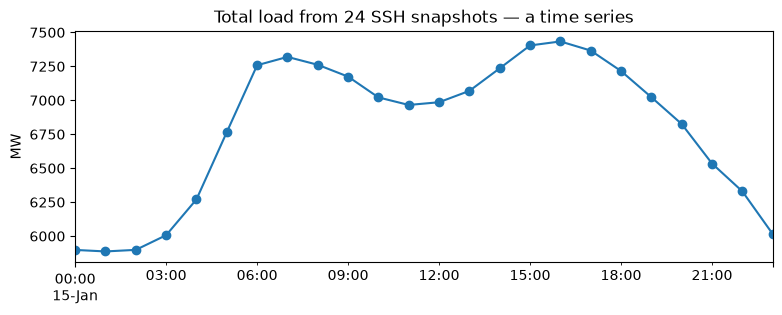

In [6]:
import zipfile
import pandas as pd
zf = zipfile.ZipFile("../data/svedala-year/ssh_week.zip")
day = sorted(n for n in zf.namelist() if "2025-01-15" in n)
print(len(day), "snapshots for 2025-01-15")
# Loop the 24 files of one day: read each snapshot, take its scenarioTime and
# the sum of all ConformLoad P values -> one (timestamp, total MW) pair each.
rows = {}
for n in day:
    txt = zf.read(n).decode("utf-8")
    ts = re.search(r"scenarioTime>([^<]+)<", txt).group(1)
    total = sum(float(p) for _, p in re.findall(
        r'<cim:ConformLoad rdf:about="#(_[0-9a-f-]+)">\s*<cim:EnergyConsumer.p>([-\d.]+)', txt))
    rows[pd.Timestamp(ts)] = total
series = pd.Series(rows).sort_index()
print(f"{series.min():.0f} to {series.max():.0f} MW over the day")
ax = series.plot(figsize=(9, 3), marker="o", title="Total load from 24 SSH snapshots — a time series")
ax.set_ylabel("MW");

One day, per hour, assembled from files that each describe a single instant. Lab 6 does this properly: all 168 hours, **per zone** (the EQ join gives each load its zone via the CSVs), into a tidy DataFrame checked against the course dataset.

## 4. Shapes of time series — the vocabulary

The same physical reality arrives in different shapes, and the shape decides what you can model:

- **Market data vs SCADA**: ENTSO-E gives *zonal, hourly, settled* numbers; a control room gets *per-element, per-second, raw* measurements. Different questions, different data.
- **Per-element vs per-zone**: the SSH gives every load; Lab 6 aggregates to zones — an irreversible choice, because a zone total cannot be split back into its loads. *Aggregate late*: keep the per-element data as long as you can and sum only at the last step, so the detail is still there when a question needs it.
- **Wide vs long**: one column per zone (wide — good for modelling) or one row per (time, zone, value) (long — good for storage and joins). `pd.melt` goes wide → long and `pivot` goes long → wide; the next cell shows both.

### 4.1 Wide and long, side by side

`pd.DataFrame({...}, index=pd.to_datetime([...]))` builds a two-hour, two-zone table with timestamps as the index. `reset_index(names="timestamp")` turns the index into an ordinary column; `.melt(id_vars="timestamp", var_name="zone", value_name="mw")` unpivots the zone columns into rows — one row per (timestamp, zone). `pivot(index=..., columns=..., values=...)` is the reverse: which column becomes the rows, which becomes the columns, which fills the cells. **What you see:** the wide table (2 rows × 2 zone columns), the long table with 4 rows and the columns `timestamp, zone, mw`, and the pivoted table — the wide shape back again, with `zone` as the column heading. Same four numbers, three prints.

In [7]:
wide = pd.DataFrame({"ZON_A": [1.0, 2.0], "ZON_B": [3.0, 4.0]},
                    index=pd.to_datetime(["2025-01-01 00:00", "2025-01-01 01:00"]))
long = wide.reset_index(names="timestamp").melt(id_vars="timestamp",
                                                var_name="zone", value_name="mw")
back = long.pivot(index="timestamp", columns="zone", values="mw")   # long -> wide again
print(wide, "\n\n", long, "\n\n", back)

                     ZON_A  ZON_B
2025-01-01 00:00:00    1.0    3.0
2025-01-01 01:00:00    2.0    4.0 

             timestamp   zone   mw
0 2025-01-01 00:00:00  ZON_A  1.0
1 2025-01-01 01:00:00  ZON_A  2.0
2 2025-01-01 00:00:00  ZON_B  3.0
3 2025-01-01 01:00:00  ZON_B  4.0 

 zone                 ZON_A  ZON_B
timestamp                        
2025-01-01 00:00:00    1.0    3.0
2025-01-01 01:00:00    2.0    4.0


## Self-check

Three `assert` lines: at least 55 loads joined — the join here gives 73, and 55 is the floor Lab 6's zone map must reach, so the same number guards both; the base-case total within 200 MW of 10 981, and a day of 24 hours whose peak is at least 10 % above its trough (`series.max() > series.min() * 1.1`). **What you see:** `ALL OK — you have read CIM by hand. Lab 6 industrialises it.`

In [8]:
assert len(joined) >= 55, "EQ/SSH join lost too many loads"
assert abs(sum(joined.values()) - 10981) < 200, "SSH base-case total looks wrong"
assert len(series) == 24 and series.max() > series.min() * 1.1
print("ALL OK — you have read CIM by hand. Lab 6 industrialises it.")

ALL OK — you have read CIM by hand. Lab 6 industrialises it.


## 5. What you take to Lab 6

Three things: a snapshot is one instant and a folder of snapshots is a time series; the join between EQ names and SSH values goes through mRIDs, and the CSVs are the bridge from names to zones; and the totals only agree once you have accounted for every load, mapped or not — which is why Lab 6 makes you log the unmapped ones and state a policy before you compare your week against the course dataset.